In [6]:
import mne
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam #알고리즘(optimizer)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(42) #가중치 고정

1. Introduction
Extract deep latent features from preprocessed EEG epochs using Autoencoder (following the 2025 paper).

2. Loading Preprocessed Data
Load cleaned epochs and labels from Notebook 02.

3. Data Preparation for Autoencoder
- Standardization
- split the data into train/test dataset (8:2)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# notebook2에서 저장한 PSD features data load
X_raw = np.load('X_full_dataset.npy')
y = np.load('y_full_dataset.npy')

print(f"input data features (X): {X_raw.shape}")
print(f"label data features (y): {y.shape}")
print(f"ADHD ratio: {np.mean(y)*100:.1f}%")

# StandardScaler
scaler = StandardScaler()   # Autoencoder가 효율적으로 학습하려면 평균 0, 표준편차 1로 맞춰야함
X_scaled = scaler.fit_transform(X_raw)

# train/test data split 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

input data features (X): (8400, 2755)
label data features (y): (8400,)
ADHD ratio: 55.8%
Train set: (6720, 2755)
Test set: (1680, 2755)


In [ ]:
4. Feature Extraction & Supervised Learning
  - Dataset PreparationInput Features: PSD (Power Spectral Density) mapped across 19 channels.
      Input Shape: (8400, 2755) / Target Labels: Binary classification (ADHD vs. Healthy Control).
      Scaling: Applied StandardScaler (Z-score normalization) for optimal neural network convergence.
      Data Split: To ensure rigorous evaluation, the dataset was partitioned into Train (80%) and Test (20%) sets.
  - Supervised Autoencoder (SAE) ArchitectureLatent Space (Bottleneck): Compressed to 32 dimensions to extract the most discriminative neural markers.
      **Dual-task Learning**
        Reconstruction Path: Minimizes information loss by reconstructing the input PSD.
        Classification Path: Maximizes group separability (ADHD vs. HC) using a Sigmoid output layer.
      Latent Feature Extraction: The 32D latent vector is used as the primary feature for subsequent RSA (Representational Similarity Analysis).
  - Training ParametersLoss Functions:MSE (Mean Squared Error) for reconstruction.
      Binary Crossentropy for classification.
      Optimizer: Adam
      Regularization: Batch Normalization and Dropout (0.3) to prevent overfitting.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 설정값
input_dim = X_train.shape[1]  # 2755
latent_dim = 32              # 압축될 dimensity: 32차원

# Encoder
input_layer = Input(shape=(input_dim,))
e = layers.Dense(512, activation='relu')(input_layer)
e = layers.BatchNormalization()(e) # 학습 안정화
e = layers.Dense(128, activation='relu')(e)
latent = layers.Dense(latent_dim, activation='relu', name='latent_space')(e)

# Decoder (Reconstruction Head)
d = layers.Dense(128, activation='relu')(latent)
d = layers.Dense(512, activation='relu')(d)
reconstructed = layers.Dense(input_dim, activation='linear', name='reconstruction_output')(d)

# Classifier (Classification Head) 
c = layers.Dense(32, activation='relu')(latent)
c = layers.Dropout(0.3)(c) # 과적합 방지
class_output = layers.Dense(1, activation='sigmoid', name='classification_output')(c)

# 모델 통합 및 컴파일
model = models.Model(inputs=input_layer, outputs=[reconstructed, class_output])

model.compile(
    optimizer='adam',
    loss={
        'reconstruction_output': 'mse', 
        'classification_output': 'binary_crossentropy'
    },
    loss_weights={
        'reconstruction_output': 0.5,    # 복원과 분류 비중 1:1로 설정
        'classification_output': 0.5
    },
    metrics={'classification_output': 'accuracy'}
)

# callback - learning rate reduction 
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # validation loss 줄어들지 않으면
    factor=0.2,           # 학습률을 0.2배로 감소 (ex. 0.001 -> 0.0002)
    patience=5,           # 5 에포크 동안 개선 없으면 ㄱㄱ
    min_lr=1e-6,          # 너무 작아지지 않도록 min limit 설정
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15,          # 15 에포크 동안 개선 없으면 조기 종료
    restore_best_weights=True     # 종료 후 가장 성적이 좋았던 가중치로 자동 복구
)

# fit 학습 시작
history = model.fit(
    X_train, 
    {
        'reconstruction_output': X_train, 
        'classification_output': y_train
    },
    epochs=100,
    batch_size=32,
    validation_data=(X_test, {'reconstruction_output': X_test, 'classification_output': y_test}),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - classification_output_accuracy: 0.0000e+00 - classification_output_loss: 0.3754 - loss: 0.6240 - reconstruction_output_loss: 0.8725 - val_classification_output_accuracy: 0.0000e+00 - val_classification_output_loss: 0.1857 - val_loss: 0.5094 - val_reconstruction_output_loss: 0.8330 - learning_rate: 0.0010
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - classification_output_accuracy: 0.0000e+00 - classification_output_loss: 0.1069 - loss: 0.4560 - reconstruction_output_loss: 0.8050 - val_classification_output_accuracy: 0.0000e+00 - val_classification_output_loss: 0.1713 - val_loss: 0.4832 - val_reconstruction_output_loss: 0.7936 - learning_rate: 0.0010
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - classification_output_accuracy: 0.0000e+00 - classification_output_loss: 0.0614 - loss: 0.4212 - reconstruction_output_loss: 0.7810 - val_classification_output_accuracy: 0.0000e+00 - val_classification_output_loss: 0.19

5. Latent Feature Generation
After optimizing the model using the **Train set**, the trained Encoder was applied to the **entire scaled dataset** to generate a 32-dimensional latent representation for each sample. 

In [13]:
# 'latent_space' encoder create
encoder_model = models.Model(inputs=model.input, 
                             outputs=model.get_layer('latent_space').output)

# 전체 데이터(X_scaled)를 인코더에 넣어 32차원 특징값 extract
latent_features = encoder_model.predict(X_scaled)

print(f"추출된 잠재 특징 형태: {latent_features.shape}")   # (8400, 32)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
추출된 잠재 특징 형태: (8400, 32)


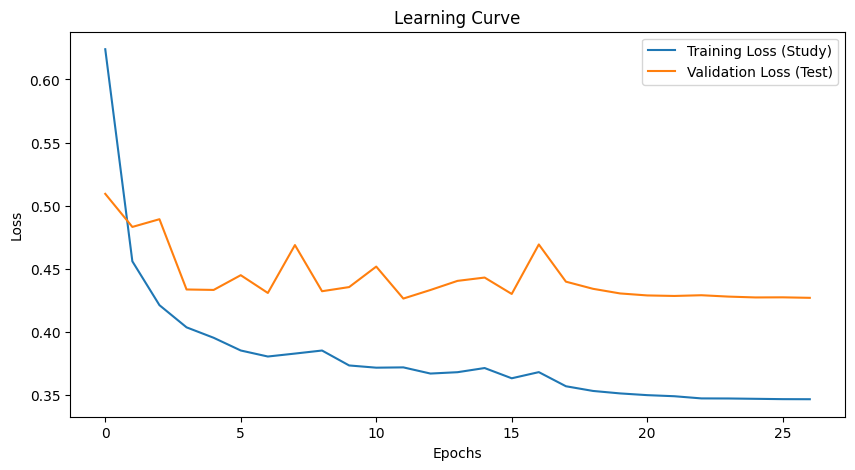

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (Study)')
plt.plot(history.history['val_loss'], label='Validation Loss (Test)') 
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
<ADHD Classification Result>
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97       743
        ADHD       0.98      0.98      0.98       937

    accuracy                           0.98      1680
   macro avg       0.98      0.97      0.98      1680
weighted avg       0.98      0.98      0.98      1680



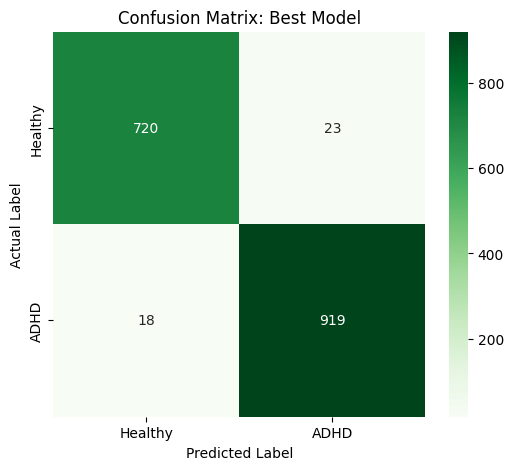

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# test dataset predict
_, y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)   # 결과값이 [복원, 분류] 두 개이므로 인덱스 [1]인 분류 결과만 가져오기

print("<ADHD Classification Result>")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'ADHD']))

# Confusion Matrix visualize
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Healthy', 'ADHD'], yticklabels=['Healthy', 'ADHD'])
plt.title('Confusion Matrix: Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


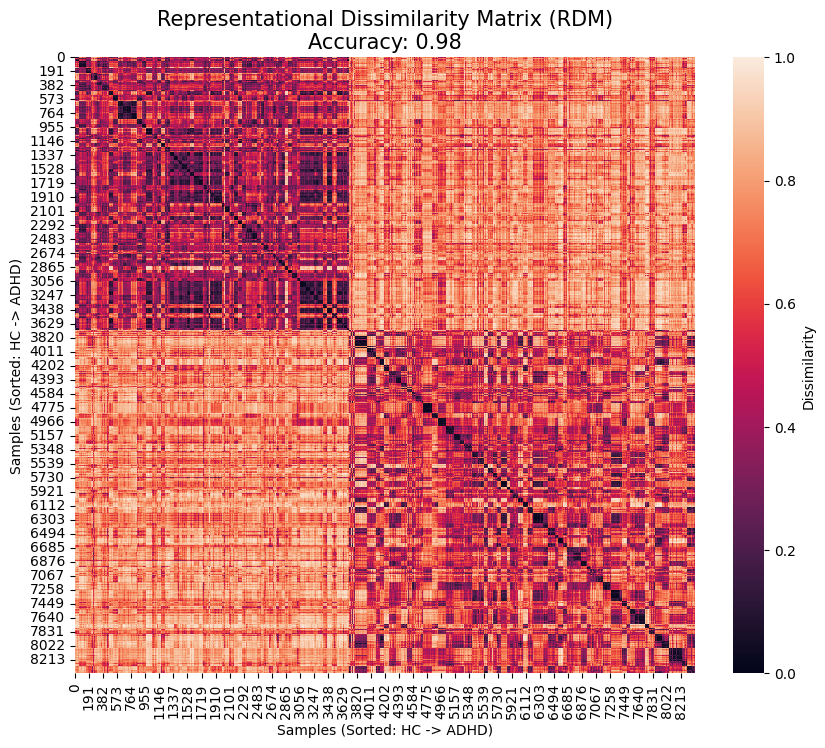

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# latent features(32차원) extracting through encoder model
encoder_model = models.Model(inputs=model.input, outputs=model.get_layer('latent_space').output)
latent_features = encoder_model.predict(X_scaled)

# 코사인 비유사도 계산 (1 - Cosine Similarity)
similarity = cosine_similarity(latent_features)   # 0에 가까울수록 유사
rdm = 1 - similarity

# 그룹별로 정렬 (시각적으로 블록 구조를 보기 위함)
indices = np.argsort(y)
rdm_sorted = rdm[indices][:, indices]   # y=0(Healthy)이 먼저 오고 y=1(ADHD)이 뒤에 오도록 정렬

# RDM 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(rdm_sorted, cmap='rocket', cbar_kws={'label': 'Dissimilarity'})
plt.title(f'Representational Dissimilarity Matrix (RDM)\nAccuracy: {0.98}', fontsize=15)
plt.xlabel('Samples (Sorted: HC -> ADHD)')
plt.ylabel('Samples (Sorted: HC -> ADHD)')
plt.show()

6. Latent Space Visualization via T-SNE
To evaluate the quality of the features extracted by the Autoencoder.

- The model successfully compressed 2,755 input features into a coherent latent space, as evidenced by the dense, non-random distribution of data points.
- Class Clear Separation: Supervised AE (with a classification head) effectively separated the ADHD (Blue) and Healthy Control (Red) groups. The minimal overlap between the two populations indicates that the model has successfully captured class-specific diagnostic biomarkers.
- High Intra-class Homogeneity: Within each cluster, data points are organized into smaller sub-clusters, suggesting that the model has preserved consistent EEG morphological patterns unique to each clinical group.

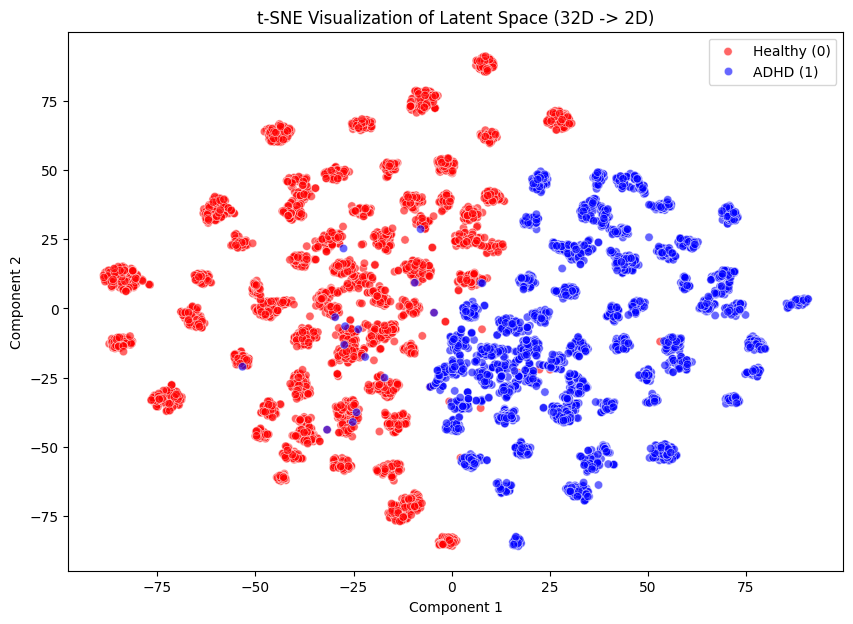

In [18]:
from sklearn.manifold import TSNE
import pandas as pd

# t-SNE 모델 생성 및 변환 (32D -> 2D)
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_features) # latent_features는 아까 추출한 (8400, 32)

# pandas dataframe
tsne_df = pd.DataFrame(latent_2d, columns=['Component 1', 'Component 2'])
tsne_df['Label'] = y 

# visualize
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Component 1', y='Component 2',
    hue='Label',
    palette=['blue', 'red'], # HC: blue, ADHD: red
    data=tsne_df,
    alpha=0.6
)
plt.title('t-SNE Visualization of Latent Space (32D -> 2D)')
plt.legend(labels=['Healthy (0)', 'ADHD (1)'])
plt.show()

7. Saving Latent Features
Save the extracted deep features for the next step (Reptile Search Algorithm).

In [19]:
import numpy as np

np.save('latent_features_32d.npy', latent_features)
np.save('labels_y.npy', y)

print(f"저장된 feature 형태: {latent_features.shape}") # (8400, 32)

저장된 feature 형태: (8400, 32)
